In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import numpy as np
import pandas as pd

from rich import print
import scvi

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import colorcet as cc
from icecream import ic

# Set SVG font type to 'none' to keep text as text in SVG files
plt.rcParams["svg.fonttype"] = "none"

In [3]:
scvi.settings.seed = 34

Seed set to 34


In [4]:
import sys
import os

# Add to the system path
sys.path.append(os.path.abspath('../breast_original'))

from params import setup # Now this should work!

In [5]:
sc.set_figure_params(dpi=150, fontsize=12, format="svg")
figure_dir = setup.FIGURES_FOLDER

plots = True

In [6]:
data_dir, data_file = setup.DATA_FOLDER, setup.DATA_FILE

data_file_name = os.path.splitext(data_file)[0]
print(data_file_name)

path_to_save = "/home/nathanl/scviva_paper/breast/checkpoints/xenium_breast_cancer_S1_R1_2"

xenium_breast_cancer_S1_R1_2

In [7]:
adata = ad.read_h5ad(path_to_save + "/xenium_breast_cancer_S1_R1_2_nicheVI.h5ad")

del adata.uns["log1p"]


print(adata)

AnnData object with n_obs × n_vars = 281780 × 313
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 
'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample', 'cell_type', 'n_genes', 
'n_counts', '_scvi_batch', '_scvi_labels', 'cell_type_coarse', 'index', '_scvi_sample'
    var: 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_coarse_colors', 'neighbors', 'pca', 'simvi_train_mask', 
'simvi_val_mask', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_scVI_MDE', 'X_scanvi', 'X_umap', 'banksy_pc_20_lambda_0.0', 
'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.5', 'ln_s10_w400_scanvi_lr0.0005_poisson_X_nicheVI', 
'ln_s20_w400_scanvi_lr0.0005_poisson_X_nicheVI', 'neighborhood_composition', 'niche_distances', 'niche_indexes', 
'qz1_m', 'qz1_m_niche_ct', 'simvi_both', 'simvi_both_08', 'simvi_both_MDE', 'simvi_both_MDE_08', 'simvi_interact', 
'simvi_interact_08', 'simvi_interact_MDE', 'simvi_interact_MDE_08', 'simvi_intrinsic', 'simvi_intrinsic_08', 
'simvi_intrinsic_MDE', 'simvi_intrinsic_MDE_08', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [8]:
from sklearn.preprocessing import MinMaxScaler

adata.layers["counts_log1p"] = adata.layers["counts"].copy()
sc.pp.log1p(adata, layer="counts_log1p")

adata.layers["standard_scaled"] = adata.layers["counts_log1p"].copy()
sc.pp.scale(adata, max_value=None, layer="standard_scaled")

adata.layers["min_max_scaled"] = MinMaxScaler().fit_transform(
    adata.layers["counts_log1p"].toarray()
)

adata.layers["min_max_scaled_raw"] = MinMaxScaler().fit_transform(
    adata.layers["counts"].toarray()
)

/home/nathanl/miniforge3/envs/scvi/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [9]:
adata_not_endo = adata[adata.obs[setup.CELL_TYPE] != 'Endothelial'].copy()

In [10]:
adata_astro = adata[adata.obs[setup.CELL_TYPE] == "Endothelial"].copy()
# del adata_astro.uns["log1p"]

print(adata_astro)

AnnData object with n_obs × n_vars = 15628 × 313
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 
'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample', 'cell_type', 'n_genes', 
'n_counts', '_scvi_batch', '_scvi_labels', 'cell_type_coarse', 'index', '_scvi_sample'
    var: 'mt', 'mean', 'std'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_coarse_colors', 'neighbors', 'pca', 'simvi_train_mask', 
'simvi_val_mask', 'umap', 'log1p'
    obsm: 'X_pca', 'X_scVI', 'X_scVI_MDE', 'X_scanvi', 'X_umap', 'banksy_pc_20_lambda_0.0', 
'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.5', 'ln_s10_w400_scanvi_lr0.0005_poisson_X_nicheVI', 
'ln_s20_w400_scanvi_lr0.0005_poisson_X_nicheVI', 'neighborhood_composition', 'niche_distances', 'niche_indexes', 
'qz1_m', 'qz1_m_niche_ct', 'simvi_both', 'simvi_both_08', 'simvi_both_MDE', 'simvi_both_MDE_08', 'simvi_interact', 
'simvi_interact_08', 'simvi_interact_MDE', 'simvi_interact_MDE_08', 'simvi_intrinsic', 'simvi_intrinsic_08', 
'simvi_intrinsic_MDE', 'simvi_intrinsic_MDE_08', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'counts_log1p', 'standard_scaled', 'min_max_scaled', 'min_max_scaled_raw'
    obsp: 'connectivities', 'distances'

# HOTSPOT

In [11]:
import hotspot

# latent_obsm_key = "ln_s10_w400_scanvi_lr0.0005_poisson_X_nicheVI"
# latent_obsm_key = "X_scanvi"
latent_obsm_key = setup.COORDS

adata_astro.layers["counts_csc"] = adata_astro.layers["counts"].tocsc()
hs = hotspot.Hotspot(
    adata_astro,
    layer_key="counts_csc",
    model="danb",
    latent_obsm_key=latent_obsm_key,
    # umi_counts_obs_key="total_counts"
)

hs.create_knn_graph(
    weighted_graph=False,
    n_neighbors=30,
)

hs_results = hs.compute_autocorrelations(jobs=-1)
hs_results.head(15)

adata_astro.uns[f"results_{latent_obsm_key}"] = hs_results.loc[hs_results.FDR < 0.05]

100%|██████████| 313/313 [00:00<00:00, 729.68it/s]


In [12]:
# Select the genes with significant lineage autocorrelation
hs_genes = hs_results.loc[hs_results.FDR < 0.05].sort_values("Z", ascending=False).index

# Compute pair-wise local correlations between these genes
lcz = hs.compute_local_correlations(hs_genes, jobs=-1)

modules = hs.create_modules(min_gene_threshold=15, core_only=True, fdr_threshold=0.05)

module_scores = hs.calculate_module_scores()

# Convert all column names to strings
module_scores.columns = module_scores.columns.map(str)


hs.results.join(hs.modules)
adata_astro.obsm[f"modules_scores{latent_obsm_key}"] = module_scores
adata_astro.uns[f"results_{latent_obsm_key}"] = hs_results.join(hs.modules).loc[
    hs_results.FDR < 0.05
]

modules.value_counts()

Computing pair-wise local correlation on 279 features...


100%|██████████| 38781/38781 [00:15<00:00, 2570.43it/s]


Computing scores for 6 modules...


100%|██████████| 6/6 [00:00<00:00, 11.68it/s]


Module
 1    67
-1    66
 2    40
 3    40
 6    24
 4    22
 5    20
Name: count, dtype: int64

In [13]:
# Get the maximum score and its column for each row
max_scores = adata_astro.obsm[f"modules_scores{latent_obsm_key}"].max(axis=1)
max_columns = adata_astro.obsm[f"modules_scores{latent_obsm_key}"].idxmax(axis=1)

WEAK_THRESHOLD = 0.5

# Apply the condition: keep the column name if max score > 1, else set it to 'weak'
adata_astro.obs["max_module"] = np.where(
    max_scores > WEAK_THRESHOLD, max_columns, "weak"
)

module_cols = []
for c in adata_astro.obsm[f"modules_scores{latent_obsm_key}"].columns:
    key = f"Module {c}"
    adata_astro.obs[key] = adata_astro.obsm[f"modules_scores{latent_obsm_key}"][c]
    module_cols.append(key)

adata_astro.write_h5ad(path_to_save + "/xenium_breast_cancer_S1_R1_2_nicheVI_CD8.h5ad")

adata_astro.obs["max_module"].value_counts()

max_module
1       4246
2       2405
6       2072
5       2060
3       1983
4       1804
weak    1058
Name: count, dtype: int64

/tmp/ipykernel_609418/907552353.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


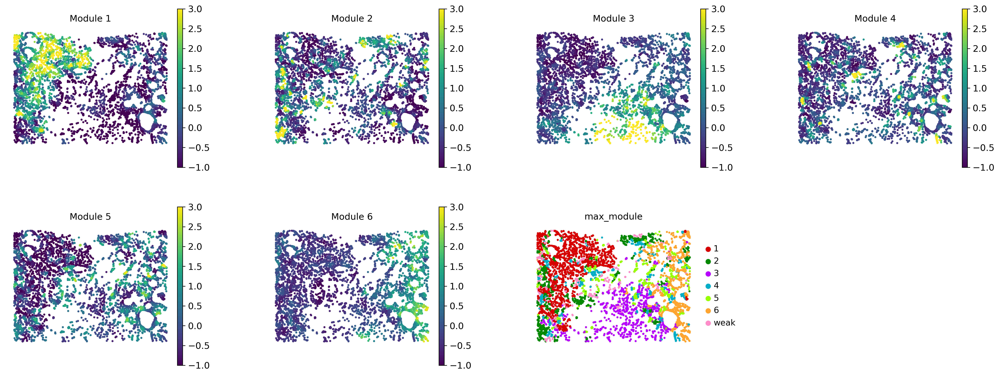

In [14]:
for sample in adata.obs[setup.SAMPLE].unique().tolist()[:1]:
    sc.pl.spatial(
        adata_astro[adata_astro.obs[setup.SAMPLE] == sample],
        spot_size=100,
        color=module_cols + ["max_module"],
        ncols=4,
        frameon=False,
        # title=f"endothelial spatial modules {sample}",
        palette=cc.glasbey_light,
        show=False,
        use_raw=False,
        wspace=0.4,
        vmin=-1,
        vmax=3,
        # vmax=global_vmax,
    )
    # plt.savefig(
    #     f"{figure_dir}endothelial_spatial_modules_xenium.png",
    #     bbox_inches="tight",
    #     dpi=1000,
    # )
    # plt.savefig(
    #     f"{figure_dir}endothelial_spatial_modules_xenium.svg",
    #     bbox_inches="tight",
    #     dpi=1000,
    # )

In [15]:
# Step 1: Calculate the global 96th percentile for vmax
global_vmax = adata_astro.obs[module_cols].stack().quantile(0.98)

# nicheDE

In [16]:
if setup.EXPRESSION_MODEL == "scanvi":
    scvivae = scvi.model.SCANVI.load(
        dir_path=path_to_save
        + f"/{setup.EXPRESSION_MODEL}vae_E"
        + str(setup.N_EPOCHS_SCVI)
        + "_"
        + str(setup.LIKELIHOOD)
        + ".pt",
        adata=adata,
        accelerator="cpu",
    )
if setup.EXPRESSION_MODEL == "scvi":
    scvivae = scvi.model.SCVI.load(
        dir_path=path_to_save
        + f"/{setup.EXPRESSION_MODEL}vae_E"
        + str(setup.N_EPOCHS_SCVI)
        + "_"
        + str(setup.LIKELIHOOD)
        + ".pt",
        adata=adata,
        accelerator="cpu",
    )

INFO     File ../breast_original/checkpoints/xenium_breast_cancer_S1_R1_2/scanvivae_E1001_poisson.pt/model.pt      
         already downloaded                                                                                        


In [17]:
MODEL = "ln_s10_w400_scanvi_lr0.0005_poisson"

In [18]:
from nichevi import nicheSCVI
# from scvi.external import nicheSCVI
# from nichevi.differential_expression import plot_DE_results, _fdr_de_prediction
from classifier import plot_DE_results

model = MODEL

path_to_save_nichevae = (
    path_to_save + "/nichevae_" + model + "_" + str(setup.N_EPOCHS_NICHEVI_DE) + ".pt"
)

nichevae = nicheSCVI.load(
    dir_path=path_to_save_nichevae,
    adata=adata,
    accelerator="cpu",
)

INFO     File                                                                                                      
         ../breast_original/checkpoints/xenium_breast_cancer_S1_R1_2/nichevae_ln_s10_w400_scanvi_lr0.0005_poisson_1
         000.pt/model.pt already downloaded                                                                        


In [19]:
adata.obs["max_module"] = "Unknown"
adata.obs.loc[adata.obs[setup.CELL_TYPE] == "Endothelial", "max_module"] = (
    adata_astro.obs["max_module"]
)

In [20]:
adata.obs.max_module.value_counts()

max_module
Unknown    266152
1            4246
2            2405
6            2072
5            2060
3            1983
4            1804
weak         1058
Name: count, dtype: int64

In [21]:
delta_niches = 0.03
delta_markers = 0.03
DELTA = [delta_niches, delta_markers, delta_niches, delta_niches]
FDR = 0.2
G1 = "1"
G2 = "3"
PSEUDO = 1e-4
N_SAMPLES_DE = 1e5

DE_1_3 = nichevae.differential_expression(
    adata,
    # groupby="kmeans_alpha_5",
    groupby="max_module",
    group1=G1,
    group2=G2,
    batch_correction=False,
    radius=None,
    k_nn=6,
    delta=DELTA,
    niche_mode=True,
    n_samples_overall=N_SAMPLES_DE,
    fdr_target=FDR,
    # weights="importance",
    pseudocounts=PSEUDO,
)


# DE_3_1 = nichevae.differential_expression(
#     adata,
#     # groupby="kmeans_alpha_5",
#     groupby="max_module",
#     group1=G2,
#     group2=G1,
#     batch_correction=False,
#     radius=None,
#     k_nn=6,
#     delta=DELTA,
#     niche_mode=True,
#     n_samples_overall=N_SAMPLES_DE,
#     fdr_target=FDR,
#     # weights="importance",
#     pseudocounts=PSEUDO,
# )

Computing adjusted nearest neighbors...

Using all 2 samples


Mean number of neighbors: 2.7 ± 2.1


Computing DE...

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

...

Running DE for group1_neighbors1

Running DE for neighbors1_group2

Running DE for neighbors1_neighbors2

Computing g1 confidence scores...

/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 10.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [22]:
PROBA_TRES  = 0.75
PLOT_MARGIN = 0.2

g1_markers = DE_1_3.gpc.y_  # (boolean vector)
# g2_markers = DE_3_1.gpc.y_train_

## DE_1_3 analysis T test

In [23]:
# Compute min_cells as 1% of endothelial cells (rounded up)
min_cells = max(1, int(0.01 * adata_astro.n_obs))

# Apply gene filtering on the subset
sc.pp.filter_genes(adata_astro, min_cells=min_cells)

# Get the list of genes that passed the filtering
filtered_genes = adata_astro.var_names

# Filter the original dataset to retain only those genes
adata = adata[:, filtered_genes].copy()

adata

AnnData object with n_obs × n_vars = 281780 × 313
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample', 'cell_type', 'n_genes', 'n_counts', '_scvi_batch', '_scvi_labels', 'cell_type_coarse', 'index', '_scvi_sample', 'max_module', '_scvi_raw_norm_scaling'
    var: 'mt', 'mean', 'std'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_coarse_colors', 'neighbors', 'pca', 'simvi_train_mask', 'simvi_val_mask', 'umap', 'log1p', 'adjusted_A'
    obsm: 'X_pca', 'X_scVI', 'X_scVI_MDE', 'X_scanvi', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.5', 'ln_s10_w400_scanvi_lr0.0005_poisson_X_nicheVI', 'ln_s20_w400_scanvi_lr0.0005_poisson_X_nicheVI', 'neighborhood_composition', 'niche_distances', 'niche_indexes', 'qz1_m', 'qz1_m_niche_ct', 'simvi_both', 'simvi_both_08', 'simvi_both_MDE', 'simvi_both_MDE_08', 'simvi_interact', 'simvi_inter

In [24]:
adata.obs.reset_index(inplace=True)

In [25]:
# Annotate groups
adata.obs["group"] = "other"  # Default category
adata.obs.loc[DE_1_3.n1_index, "group"] = "N1"
adata.obs.loc[DE_1_3.n2_index, "group"] = "N2"
adata.obs.loc[adata.obs["max_module"] == "1", "group"] = "G1"
adata.obs.loc[adata.obs["max_module"] == "3", "group"] = "G2"

In [26]:
adata.obs["group"].value_counts()

group
other    257017
N1        13141
N2         5393
G1         4246
G2         1983
Name: count, dtype: int64

In [31]:
# Filter to relevant groups (excluding 'other', 'N1', 'N2')
groups_of_interest = ["G1", "G2", "N1", "N2"]
adata.obs_names = adata.obs_names.astype(str)
adata_filtered = adata[adata.obs["group"].isin(groups_of_interest)].copy()

# Optionally remove unused categories
adata_filtered.obs["group"] = adata_filtered.obs["group"].astype("category")

cell_type_counts = adata_filtered.obs["cell_type"].value_counts()
valid_types = cell_type_counts[cell_type_counts >= 25].index
adata_filtered = adata_filtered[adata_filtered.obs[setup.CELL_TYPE].isin(valid_types)].copy()

# One-hot encode the 'cell_type' column
onehot_df = pd.get_dummies(adata_filtered.obs[setup.CELL_TYPE]).astype(np.uint8)
adata_filtered.obsm["cell_type_onehot"] = onehot_df.values.astype(np.float32)
adata_filtered.uns["cell_type_onehot_columns"] = onehot_df.columns.tolist()


adata_filtered.uns = {"cell_type_onehot_columns": adata_filtered.uns["cell_type_onehot_columns"]}

# Save to file (HDF5 format readable by R's anndata)
adata_filtered.write("adata_cside_xenium.h5ad")

adata_G1G2 = adata_filtered[adata_filtered.obs["group"].isin(["G1", "G2"])].copy()
adata_G1G2.write("adata_G1_G2.h5ad")

adata_G1N1 = adata_filtered[adata_filtered.obs["group"].isin(["G1", "N1"])].copy()
adata_G1N1.write("adata_G1_N1.h5ad")

In [32]:
adata_G1N1.obsm["cell_type_onehot"].sum(axis=0)

array([ 293.,  552.,  671.,   26.,   54., 4246.,   17., 3642., 1442.,
        108.,   14.,  418.,  230.,  389., 4477.,   77.,  162.,  552.],
      dtype=float32)

In [35]:
# Cross-tabulate cell types by group
cell_type = setup.CELL_TYPE  # e.g., "cell_type"
pd.crosstab(adata_filtered.obs[cell_type], adata_filtered.obs["group"])

group,G1,G2,N1,N2
cell_type,,,,
B_Cells,0,0,293,174
CD4+_T_Cells,0,0,552,104
CD8+_T_Cells,0,0,671,155
DCIS_1,0,0,26,63
DCIS_2,0,0,54,11
Endothelial,4246,1983,0,0
IRF7+_DCs,0,0,17,12
Invasive_Tumor,0,0,3642,55
Macrophages_1,0,0,1442,369


In [29]:
adata_filtered.obsm["cell_type_onehot"]

array([[0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [28]:
# METHOD = "wilcoxon"
METHOD = "t-test"

sc.tl.rank_genes_groups(
    adata,
    groupby="group",
    groups=["G1"],
    reference="G2",
    method=METHOD,
    key_added="rank_genes_groups_G1G2",
    use_raw=False,
    # pts=True,
    # n_genes=None,
)

sc.tl.rank_genes_groups(
    adata,
    groupby="group",
    groups=["G1"],
    reference="N1",
    method=METHOD,
    key_added="rank_genes_groups_G1N1",
    use_raw=False,
    # pts=True,
    # n_genes=None,
)

sc.tl.rank_genes_groups(
    adata,
    groupby="group",
    groups=["N1"],
    reference="G2",
    method=METHOD,
    key_added="rank_genes_groups_N1G2",
    use_raw=False,
    # pts=True,
    # n_genes=None,
)

In [29]:
adata.var

,mt,mean,std
ABCC11,False,0.385795,0.649223
ACTA2,False,0.726300,0.771478
ACTG2,False,0.748194,0.666479
ADAM9,False,0.562854,0.609893
ADGRE5,False,0.170391,0.357211
...,...,...,...
VWF,False,0.193670,0.501498
WARS,False,0.366270,0.493942
ZEB1,False,0.252417,0.460052
ZEB2,False,0.569726,0.696032


In [30]:
log2fc_min = None
pval_cutoff = None


df_G1G2 = sc.get.rank_genes_groups_df(
    adata,
    group='G1',
    key="rank_genes_groups_G1G2",
    # gene_symbols="feature_name",
    log2fc_min=log2fc_min,
    pval_cutoff=pval_cutoff,
)

df_G1G2.index = df_G1G2["names"]
lfc_G1G2 = df_G1G2["logfoldchanges"]


df_G1N1 = sc.get.rank_genes_groups_df(
    adata,
    group='G1',
    key="rank_genes_groups_G1N1",
    # gene_symbols="feature_name",
    log2fc_min=log2fc_min,
    pval_cutoff=pval_cutoff,
)

df_G1N1.index = df_G1N1["names"]
lfc_G1N1 = df_G1N1["logfoldchanges"]

df_N1G2 = sc.get.rank_genes_groups_df(
    adata,
    group='N1',
    key="rank_genes_groups_N1G2",
    # gene_symbols="feature_name",
    log2fc_min=log2fc_min,
    pval_cutoff=pval_cutoff,
)

df_N1G2.index = df_N1G2["names"]
lfc_N1G2 = df_N1G2["logfoldchanges"]

In [31]:
fdr_G1N1 = (df_G1N1["pvals_adj"] < 0.05) & (df_G1N1["logfoldchanges"] > 0)
g1_g2_genes = sc.get.rank_genes_groups_df(
    adata,
    group="G1",
    key="rank_genes_groups_G1G2",
    # gene_symbols="feature_name",
    log2fc_min=0,
    pval_cutoff=0.05,
)["names"]

In [32]:
g1_g2_genes.index = g1_g2_genes.values

In [33]:
fdr_G1N1.loc[g1_g2_genes.index].shape

(86,)

In [34]:
fdr_G1N1.sum()

90

In [49]:
len(g1_g2_genes)

86

In [37]:
from classifier import _gaussian_process_classifier, plot_DE_results

In [38]:
lfc_G1G2

names
ESM1       4.825180
FOXA1      3.183466
CCND1      2.114262
KRT7       2.441722
TCIM       2.286225
             ...   
ANKRD29   -2.661515
SFRP1     -3.238238
CAVIN2    -2.767906
PDK4      -2.442284
ADH1B     -5.529602
Name: logfoldchanges, Length: 290, dtype: float32

In [39]:
gpc = _gaussian_process_classifier(
    lfc_g1_g2=lfc_G1G2.loc[g1_g2_genes],
    lfc_n1_g2=lfc_N1G2.loc[g1_g2_genes],
    fdr_g1_n1=fdr_G1N1.loc[g1_g2_genes],
    # lenght_scale_init=10,
    # alpha_init=1,
    # lenght_scale_bounds=(10, 100),
    # alpha_bounds = (1e-1, 1e-0),
)

gpc.train_score_

/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 10.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


1.0

/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GaussianProcessClassifier was fitted with feature names
  warnings.warn(


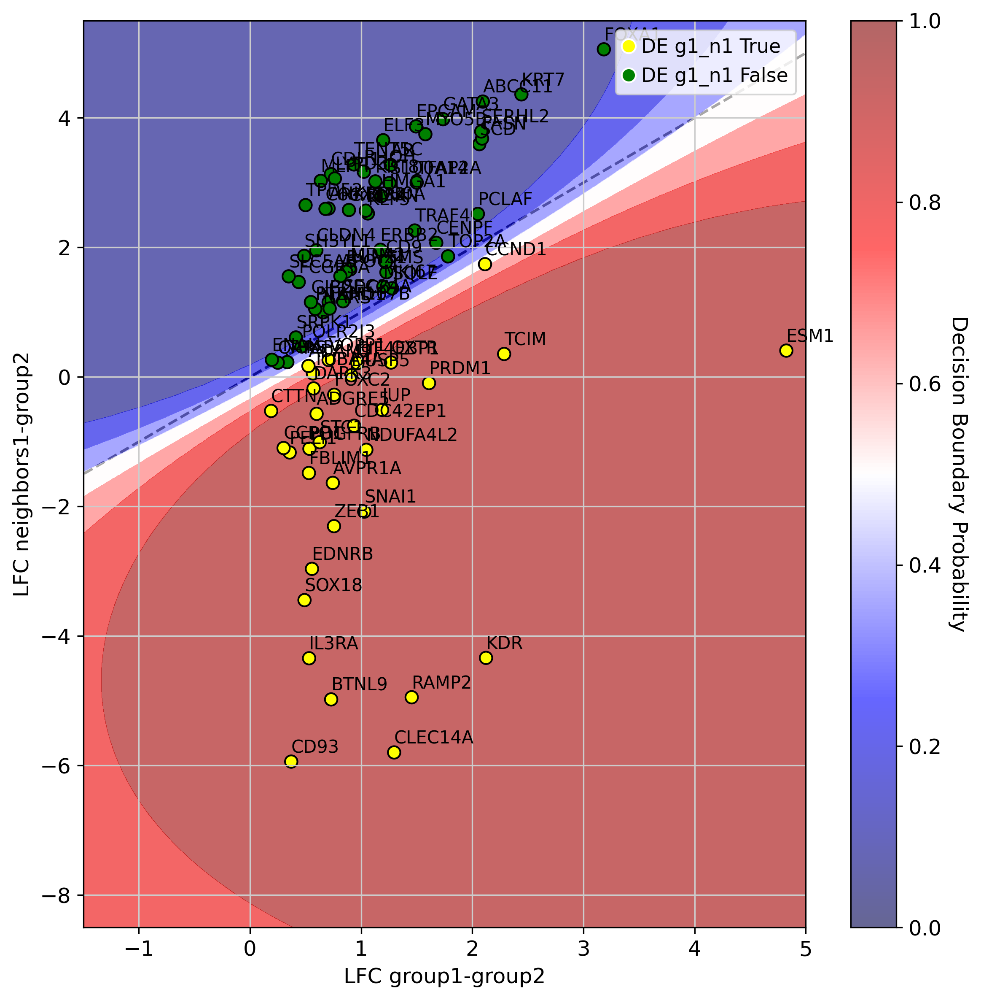

In [58]:
plot_DE_results(
    gpc=gpc,
    X=None,
    y=None,
    filter=g1_g2_genes,
    path_to_save=f"{setup.FIGURES_2DE_FOLDER}scatter_DE_ttest_xenium.svg",
    margin=PLOT_MARGIN,
    manual_limits=(-1.5, 5, -8.5, 5.5),
)

yellow_genes_g1_g2 = gpc.confident_genes
blue_genes_g1_g2 = set(g1_g2_genes) - set(yellow_genes_g1_g2)

In [55]:
blue_genes_g1_g2

{'ABCC11',
 'ANKRD30A',
 'APOC1',
 'AR',
 'C6orf132',
 'CCDC6',
 'CD9',
 'CDH1',
 'CENPF',
 'CLDN4',
 'CXCR4',
 'DMKN',
 'ELF3',
 'ENAH',
 'EPCAM',
 'ERBB2',
 'FAM107B',
 'FASN',
 'FCGR3A',
 'FOXA1',
 'GATA3',
 'GJB2',
 'HMGA1',
 'KLF5',
 'KRT7',
 'KRT8',
 'LYPD3',
 'MDM2',
 'MKI67',
 'MLPH',
 'MYO5B',
 'NARS',
 'PCLAF',
 'POLR2J3',
 'PTRHD1',
 'QARS',
 'RHOH',
 'RUNX1',
 'S100A14',
 'SCD',
 'SEC24A',
 'SERHL2',
 'SH3YL1',
 'SLC5A6',
 'SMS',
 'SQLE',
 'SRPK1',
 'TENT5C',
 'TFAP2A',
 'THAP2',
 'TOP2A',
 'TPD52',
 'TRAF4'}

In [41]:
lfc_G1G2

names
ESM1       4.825180
FOXA1      3.183466
CCND1      2.114262
KRT7       2.441722
TCIM       2.286225
             ...   
ANKRD29   -2.661515
SFRP1     -3.238238
CAVIN2    -2.767906
PDK4      -2.442284
ADH1B     -5.529602
Name: logfoldchanges, Length: 290, dtype: float32

In [44]:
gpc.gene_probas_.index

Index(['ESM1', 'FOXA1', 'CCND1', 'KRT7', 'TCIM', 'KDR', 'SCD', 'FASN', 'PCLAF',
       'GATA3', 'RAMP2', 'SERHL2', 'CLEC14A', 'PRDM1', 'ABCC11', 'TOP2A',
       'EPCAM', 'ERBB2', 'TRAF4', 'SMS', 'CENPF', 'MYO5B', 'CD9', 'SQLE',
       'JUP', 'KRT8', 'TFAP2A', 'S100A14', 'HMGA1', 'AR', 'MDM2', 'MKI67',
       'SNAI1', 'RUNX1', 'EIF4EBP1', 'DUSP5', 'CXCR4', 'ZEB1', 'SEC24A',
       'CDC42EP1', 'OXTR', 'TENT5C', 'KLF5', 'VOPP1', 'CCDC6', 'NARS',
       'FAM107B', 'RHOH', 'ANKRD30A', 'ELF3', 'APOC1', 'BTNL9', 'AVPR1A',
       'POLR2J3', 'NDUFA4L2', 'CDH1', 'CD93', 'ADGRE5', 'TUBA4A', 'ADAM9',
       'MLPH', 'EDNRB', 'LYPD3', 'PDGFRB', 'IL3RA', 'FBLIM1', 'STC1', 'PTRHD1',
       'FOXC2', 'DMKN', 'TPD52', 'SH3YL1', 'DAPK3', 'SOX18', 'SRPK1', 'CLDN4',
       'GJB2', 'PELI1', 'FCGR3A', 'CCPG1', 'C6orf132', 'SLC5A6', 'THAP2',
       'QARS', 'CTTN', 'ENAH'],
      dtype='object', name='names')

In [43]:
g1_g2_genes[gpc.gene_probas_>0.9].index

Index(['ESM1', 'TCIM', 'KDR', 'RAMP2', 'CLEC14A', 'PRDM1', 'JUP', 'SNAI1',
       'DUSP5', 'ZEB1', 'CDC42EP1', 'OXTR', 'BTNL9', 'AVPR1A', 'NDUFA4L2',
       'CD93', 'ADGRE5', 'EDNRB', 'PDGFRB', 'IL3RA', 'FBLIM1', 'STC1', 'FOXC2',
       'SOX18', 'PELI1', 'CCPG1'],
      dtype='object')

# comparison with reference

In [ ]:
# Endothelial reference for Table 1: the Wu et al. 2021 atlas restricted to genes expressed in >=1% of
# endothelial cells, with the endothelial-vs-rest t-test. Built once, then read from ATLAS_DE_PATH.
ATLAS_PATH = "/home/nathanl/Data/breast_sc_atlas_wu2021.h5ad"
ATLAS_DE_PATH = "/home/nathanl/Data/breast_sc_atlas_wu2021_DE.h5ad"
if not os.path.exists(ATLAS_DE_PATH):
    _ref = ad.read_h5ad(ATLAS_PATH)
    _endo = _ref[_ref.obs["cell_type"] == "endothelial cell"].copy()
    sc.pp.filter_genes(_endo, min_cells=max(1, int(0.01 * _endo.n_obs)))
    _ref = _ref[:, _endo.var_names].copy()
    sc.tl.rank_genes_groups(
        _ref,
        groupby="cell_type",
        groups=["endothelial cell"],
        method="t-test",
        key_added="rank_genes_groups_ttest_cell_type",
        use_raw=False,
        pts=True,
        n_genes=None,
    )
    _ref.write_h5ad(ATLAS_DE_PATH)
    del _ref, _endo

In [47]:
adata_ref  = ad.read_h5ad(ATLAS_DE_PATH)
adata_ref

AnnData object with n_obs × n_vars = 100064 × 12716
    obs: 'donor_id', 'percent_mito', 'nCount_RNA', 'nFeature_RNA', 'celltype_major', 'celltype_minor', 'celltype_subset', 'subtype', 'gene_module', 'calls', 'normal_cell_call', 'CNA_value', 'batch_run', 'multiplexed', 'cryo_state', 'development_stage_ontology_term_id', 'cancer_type', 'ER', 'PR', 'HER2_IHC', 'HER2_ISH', 'HER2_ISH_ratio', 'Ki67', 'subtype_by_IHC', 'treatment_status', 'treatment_details', 'assay_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'disease_ontology_term_id', 'grade', 'cell_type_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation',

In [37]:
DE_1_3.g1_g2[
    g1_markers & (DE_1_3.g1_g2["lfc_median"] > 0) & DE_1_3.g1_g2[f"is_de_fdr_{FDR}"]
][["lfc_median", "proba_de", "proba_de_g1_n1"]].sort_values(
    by="lfc_median", ascending=False
)

,lfc_median,proba_de,proba_de_g1_n1
ESM1,3.733766,0.83633,0.999649
PRDM1,1.353008,0.81498,0.981069
KDR,1.224501,0.77562,0.997818
TCIM,1.143552,0.83050,0.997445
SNAI1,1.018414,0.76881,0.999967
DUSP5,1.000219,0.82915,0.674472
CDC42EP1,0.833604,0.82121,0.998589
ZEB1,0.716000,0.77510,0.999831
VOPP1,0.708967,0.80828,0.180369
DNTTIP1,0.369279,0.79343,0.497412


In [51]:
DE_1_3.g1_g2[
    g1_markers
    & (DE_1_3.g1_g2["lfc_median"] > 0)
    & (DE_1_3.g1_g2["proba_de"] > PROBA_TRES)
    & (DE_1_3.g1_g2["proba_de_g1_n1"] > 0.9)
][["lfc_median", f"is_de_fdr_{FDR}", "proba_de", "proba_de_g1_n1"]].sort_values(
    by="lfc_median", ascending=False
).index

/tmp/ipykernel_1146455/15241532.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  DE_1_3.g1_g2[


Index(['ESM1', 'OXTR', 'PRDM1', 'KDR', 'TCIM', 'NDUFA4L2', 'SNAI1', 'CDC42EP1',
       'ZEB1', 'DAPK3'],
      dtype='object')

In [29]:
g1_g3_genes_xenium = [
    "SQLE",
    "ESM1",
    "PCLAF",
    "CCND1",
    "CCDC6",
    "PTRHD1",
    "SMS",
    "FOXA1",
    "TCIM",
    "TRAF4",
    "SERHL2",
    "CDC42EP1",
    "KDR",
    "NARS",
    "CENPF",
    "KRT7",
    "TOP2A",
    "PRDM1",
    "ABCC11",
    "HMGA1",
    "VOPP1",
    "THAP2",
    "DUSP5",
    "SEC24A",
    "MDM2",
    "SNAI1",
    "DNTTIP1",
    "POLR2J3",
    "DMKN",
    "SCD",
    "ADAM9",
    "EIF4EBP1",
    "TFAP2A",
    "SRPK1",
    "MKI67",
    "FASN",
    "NDUFA4L2",
    "OXTR",
    "SH3YL1",
    "ZEB1",
    "MYO5B",
    "OCIAD2",
    "JUP",
    "TUBA4A",
    "RAMP2",
    "CD9",
    "CTTN",
    "GATA3",
    "S100A14",
    "GJB2",
    "KLF5",
    "RUNX1",
    "AR",
    "LYPD3",
    "EPCAM",
    "TMEM147",
    "ENAH",
    "CLEC14A",
    "TENT5C",
    "PELI1",
    "FAM107B",
]

g1_g3_genes_xenium = [
    "SQLE",
    "ESM1",
    "PTRHD1",
    "CCDC6",
    "PCLAF",
    "CCND1",
    "TCIM",
    "TRAF4",
    "HMGA1",
    "SMS",
    "NARS",
    "FOXA1",
    "CDC42EP1",
    "CENPF",
    "THAP2",
    "POLR2J3",
    "KDR",
    "KRT7",
    "SRPK1",
    "SERHL2",
    "TOP2A",
    "DNTTIP1",
    "DMKN",
    "VOPP1",
    "PRDM1",
    "TUBA4A",
    "MYO5B",
    "ABCC11",
    "ADAM9",
    "SCD",
    "MKI67",
    "SNAI1",
    "EIF4EBP1",
    "SH3YL1",
    "TFAP2A",
    "CTTN",
    "NDUFA4L2",
    "DAPK3",
    "JUP",
    "OCIAD2",
    "ZEB1",
    "DUSP5",
    "CD9",
    "SEC24A",
    "MDM2",
    "RAMP2",
    "OXTR",
    "GATA3",
    "GJB2",
    "FASN",
]

In [25]:
len(g1_g3_genes_xenium)

50

ic| g1_markers.loc[g1_g3_genes].sum(): 12
ic| len(g1_g3_genes) - g1_markers.loc[g1_g3_genes].sum(): 7
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GaussianProcessClassifier was fitted with feature names
  warnings.warn(


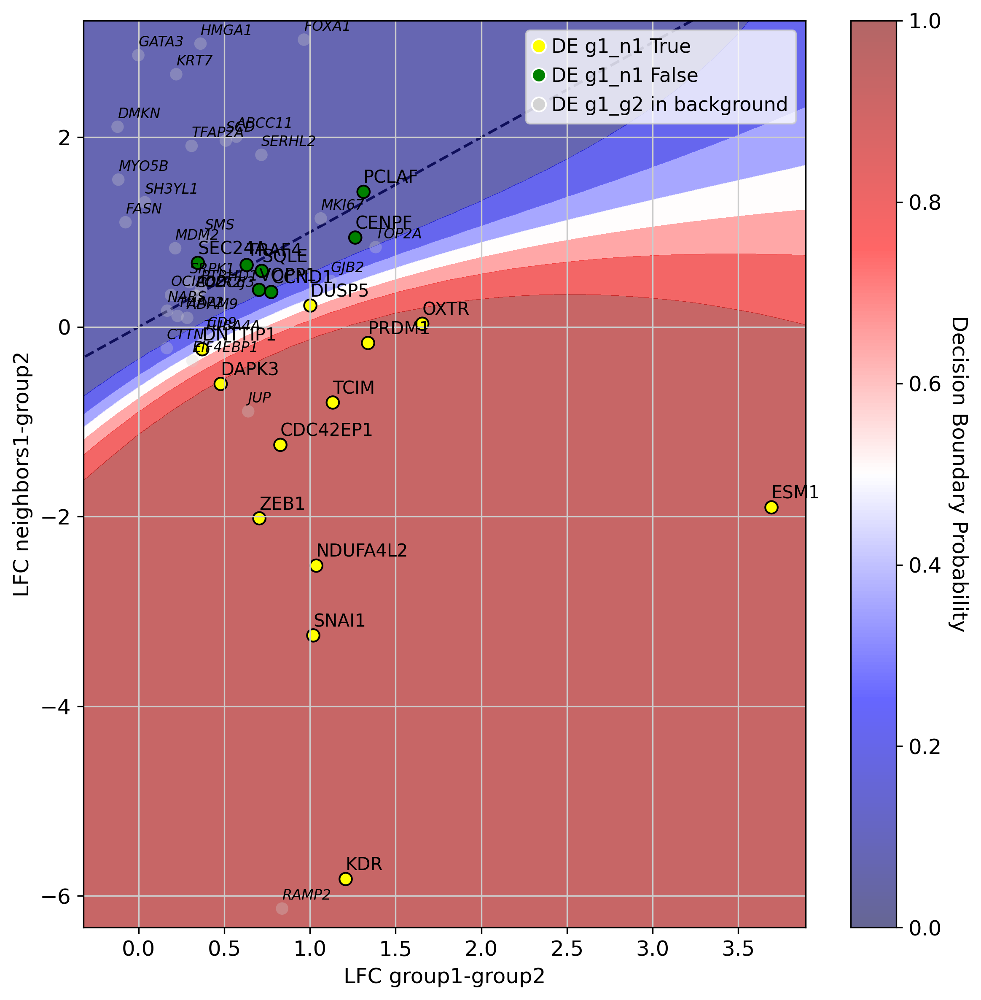

In [45]:
g1_g3_genes = DE_1_3.g1_g2[
    (DE_1_3.g1_g2["lfc_median"] > 0) & DE_1_3.g1_g2[f"is_de_fdr_{FDR}"]
].index

g1_g3_genes = DE_1_3.g1_g2[
    (DE_1_3.g1_g2["lfc_median"] > 0) & (DE_1_3.g1_g2['proba_de'] > PROBA_TRES)
].index

background_g1_g3 = list(set(g1_g3_genes_xenium) - set(g1_g3_genes))

ic(g1_markers.loc[g1_g3_genes].sum())
ic(len(g1_g3_genes) - g1_markers.loc[g1_g3_genes].sum())
plot_DE_results(
    DE_1_3.gpc,
    filter=g1_g3_genes,
    background_filter=background_g1_g3,
    # path_to_save=f"{setup.FIGURES_FOLDER}scatter_DE_proseg.svg",
    margin=PLOT_MARGIN,
    # manual_limits=(-0.5, 4.5, -5.5, 4),
)

In [31]:
yellow_genes_g1_g2 = g1_markers.loc[g1_g3_genes].values
blue_genes_g1_g2 = list(set(g1_g3_genes) - set(yellow_genes_g1_g2))

DE_1_3.gpc.confident_genes

Index(['ESM1', 'TCIM', 'DUSP5', 'CDC42EP1', 'PRDM1', 'VOPP1', 'DNTTIP1', 'KDR',
       'ZEB1', 'SNAI1', 'OXTR', 'DAPK3', 'NDUFA4L2'],
      dtype='object')

In [13]:
def get_gene_percentiles_list(adata, gene_list, p, layer=None):
    """
    Calculate the p-percentile of gene expression for a list of genes in an AnnData object.

    Parameters:
        adata (AnnData): The AnnData object containing expression data.
        gene_list (list): List of gene names for which to compute percentiles.
        p (float): Percentile to compute (between 0 and 100).
        layer (str or None): The layer from which to retrieve expression data.
                             If None, uses `adata.X`.

    Returns:
        list: A list of p-percentile values for the genes, in the same order as gene_list.
              If a gene is not found, its value will be `None`.
    """
    percentiles = []

    for gene in gene_list:
        if gene in adata.var_names:
            if layer:
                data = adata[:, gene].layers[layer].flatten()
            else:
                data = adata[:, gene].X.flatten()

            # Compute the percentile
            percentiles.append(np.percentile(data, p))
        else:
            percentiles.append(None)  # Handle genes not in adata.var_names

    return percentiles

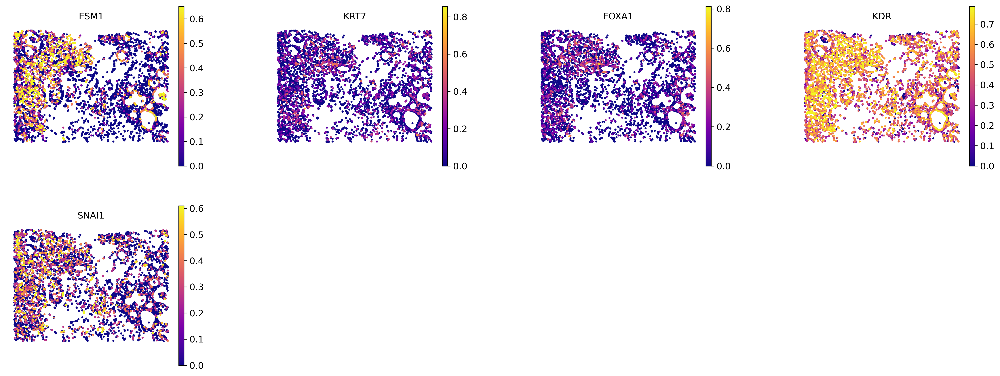

In [17]:
plot_endo = True
gene_list_invasive = ["ESM1",
            "KRT7",
            "FOXA1",
            "KDR",
            "SNAI1",
]
percentiles_invasive = get_gene_percentiles_list(
    adata, gene_list_invasive, 99.9, layer="min_max_scaled"
)

for sample in adata.obs[setup.SAMPLE].unique().tolist()[:1]:
    sc.pl.spatial(
        adata=adata_astro[adata_astro.obs[setup.SAMPLE] == sample]
        if plot_endo
        else adata_not_endo[adata_not_endo.obs[setup.SAMPLE] == sample],
        spot_size=100 if plot_endo else 40,
        # color=g3_g1_genes,
        color=gene_list_invasive,
        frameon=False,
        show=False,
        use_raw=False,
        wspace=0.4,
        vmax=percentiles_invasive,
        # vmax="p99.5",
        layer="min_max_scaled",
        cmap="plasma",
    )

    # if plot_endo:
    #     plt.savefig(f"{figure_dir}_proseg_endo.svg", bbox_inches="tight", dpi=1000)
    # else:
    #     plt.savefig(f"{figure_dir}_proseg_not_endo.svg", bbox_inches="tight", dpi=1000)

In [71]:
adata.obs.index = adata.obs['level_0']

/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


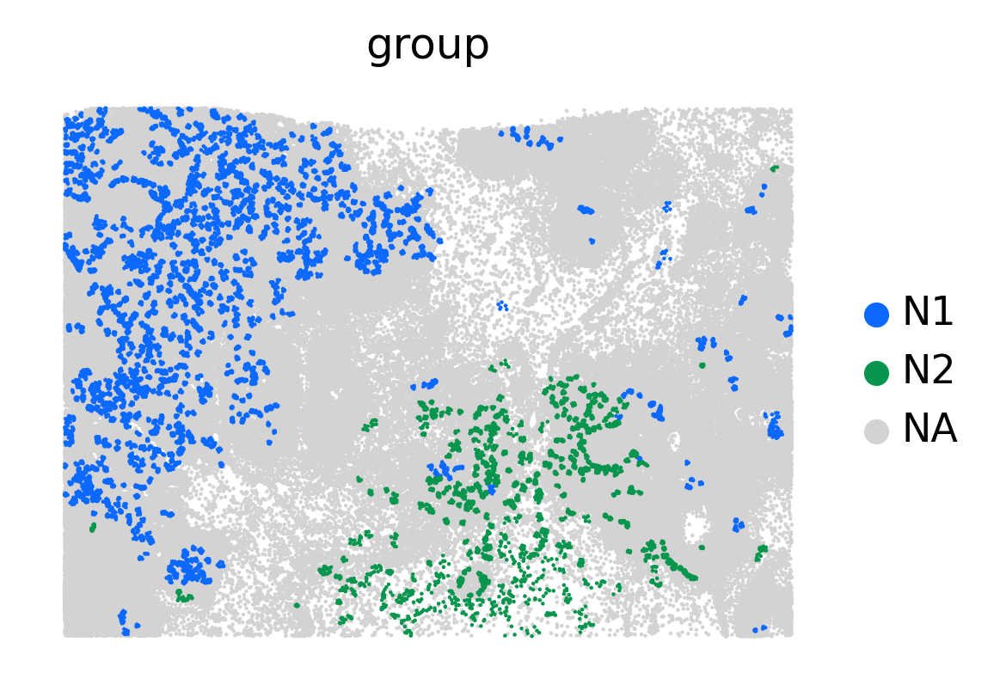

In [72]:
# adata_endo = adata[adata.obs[setup.CELL_TYPE].isin(["Endothelial"])].copy()

for sample in adata.obs[setup.SAMPLE].unique().tolist()[:1]:
    sc.pl.spatial(
        adata[adata.obs[setup.SAMPLE] == sample],
        spot_size=40,
        color=["group"],
        groups=["N1", "N2"],
        # groups=["N1"],
        ncols=4,
        frameon=False,
        palette=cc.glasbey_cool,
        # palette="tab20",
        show=False,
        use_raw=False,
        wspace=0.4,
        vmax="p96",
        sort_order=True,
    )

    plt.savefig(f"{figure_dir}_endo_neighbors.svg", bbox_inches="tight", dpi=1000)

In [73]:
print(f"{figure_dir}_endo_neighbors.svg")

/home/nathanl/niche-VI-experiments/breast_cancer/figures_journal_endo_neighbors.svg

## DE_3_1 analysis

In [150]:
DE_3_1.g1_g2[
    g2_markers & (DE_3_1.g1_g2["lfc_median"] > 0) & DE_3_1.g1_g2[f"is_de_fdr_{FDR}"]
][["lfc_median", "proba_de", "proba_de_g1_n1"]].sort_values(
    by="lfc_median", ascending=False
)

,lfc_median,proba_de,proba_de_g1_n1
TIMP4,2.710999,0.89107,0.927208
EDN1,1.578400,0.84197,0.999993
PDK4,1.396527,0.95298,0.254814
BTNL9,1.364256,0.78866,1.000000
AKR1C1,1.311156,0.85781,0.950033
ANKRD29,1.189959,0.81382,0.999999
CLDN5,1.048465,0.73448,1.000000
AKR1C3,0.997124,0.88165,0.991314
NCAM1,0.856018,0.74665,0.998841
AQP1,0.724066,0.72553,1.000000


In [149]:
DE_3_1.g1_g2[
    g2_markers
    & (DE_3_1.g1_g2["lfc_median"] > 0)
    & (DE_3_1.g1_g2["proba_de"] > PROBA_TRES)
][["lfc_median", f"is_de_fdr_{FDR}", "proba_de", "proba_de_g1_n1"]].sort_values(
    by="lfc_median", ascending=False
)

,lfc_median,is_de_fdr_0.2,proba_de,proba_de_g1_n1
TIMP4,2.710999,True,0.89107,0.927208
PDK4,1.396527,True,0.95298,0.254814
AKR1C1,1.311156,True,0.85781,0.950033
AKR1C3,0.997124,True,0.88165,0.991314
CRHBP,0.211368,True,0.87506,0.107328


In [36]:
g3_g1_genes_xenium = ['PTGDS',
 'SFRP1',
 'ADH1B',
 'EDN1',
 'KRT23',
 'CSF3',
 'PDK4',
 'AKR1C3',
 'CCDC80',
 'FGL2',
 'IL2RA',
 'ANKRD29',
 'CAVIN2',
 'DPT',
 'ALDH1A3',
 'CLDN5',
 'NCAM1',
 'IGF1',
 'PGR',
 'FBLN1',
 'CD14',
 'PDCD1LG2',
 'AKR1C1',
 'LEP',
 'OPRPN',
 'C1QA',
 'FCER1A',
 'MAP3K8',
 'CD163',
 'MRC1',
 'GZMK',
 'KRT6B',
 'CTSG',
 'ADIPOQ',
 'CPA3',
 'DSC2',
 'MEDAG',
 'CTH',
 'SDC4',
 'GNLY',
 'SFRP4'
]

DE_3_1.g1_g2.loc['CAVIN2']

proba_de                   0.76905
proba_not_de               0.23095
bayes_factor               1.25262
scale1                    0.008392
scale2                    0.003663
pseudocounts                0.0001
delta                         0.03
lfc_mean                  1.125064
lfc_median                1.231642
lfc_std                   1.502836
lfc_min                  -5.313636
lfc_max                   7.085736
raw_mean1                 2.589441
raw_mean2                 0.715325
non_zeros_proportion1     0.666667
non_zeros_proportion2     0.332192
raw_normalized_mean1     99.164057
raw_normalized_mean2     37.335176
is_de_fdr_0.2                 True
comparison                  3 vs 1
group1                           3
group2                           1
proba_de_g1_n1            0.981933
Name: CAVIN2, dtype: object

ic| g2_markers.loc[g3_g1_genes].sum(): np.int64(8)
ic| len(g3_g1_genes) - g2_markers.loc[g3_g1_genes].sum(): np.int64(39)
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GaussianProcessClassifier was fitted with feature names
  warnings.warn(


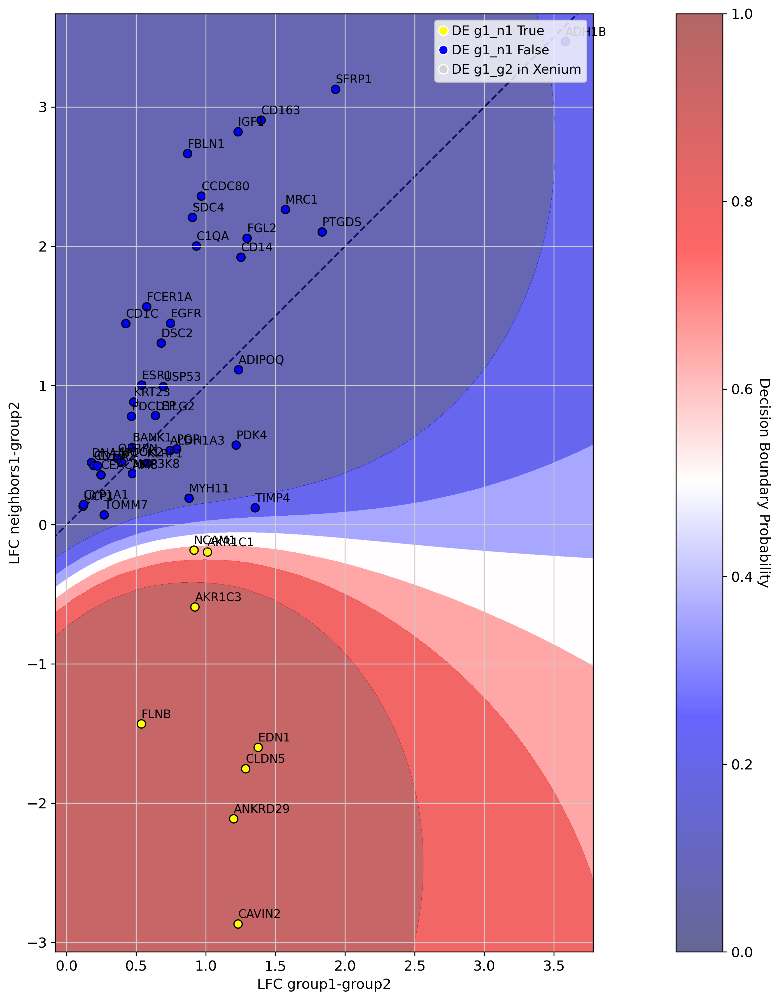

In [37]:
g3_g1_genes = DE_3_1.g1_g2[
    (DE_3_1.g1_g2["lfc_median"] > 0) & DE_3_1.g1_g2[f"is_de_fdr_{FDR}"]
].index

g3_g1_genes = DE_3_1.g1_g2[
    (DE_3_1.g1_g2["lfc_median"] > 0) & (DE_3_1.g1_g2["proba_de"] > 0.7)
].index

background_g3_g1 = list(set(g3_g1_genes_xenium) - set(g3_g1_genes))

ic(g2_markers.loc[g3_g1_genes].sum())
ic(len(g3_g1_genes) - g2_markers.loc[g3_g1_genes].sum())

plot_DE_results(
    DE_3_1.gpc,
    filter=g3_g1_genes,
    # background_filter=background_g3_g1,
    # path_to_save=f"{setup.FIGURES_FOLDER}scatter_DE_3_1_proseg.svg",
    margin=PLOT_MARGIN,
    # manual_limits=(-0, 4.0, -3, 4),
)

In [38]:
yellow_genes_g2_g1 = g2_markers.loc[g3_g1_genes].values
blue_genes_g2_g1 = list(set(g3_g1_genes) - set(yellow_genes_g2_g1))

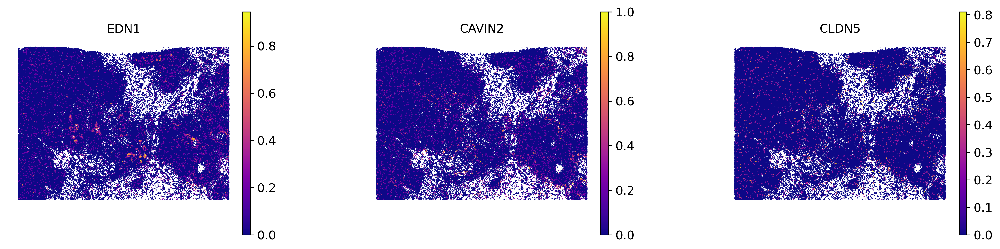

In [15]:
for sample in adata.obs[setup.SAMPLE].unique().tolist()[:1]:
    sc.pl.spatial(
        adata_not_endo[adata_not_endo.obs[setup.SAMPLE] == sample],
        # adata_astro[adata_astro.obs[setup.SAMPLE] == sample],
        spot_size=40,
        # color=g3_g1_genes,
        color=["EDN1", "CAVIN2", "CLDN5"],
        ncols=5,
        frameon=False,
        show=False,
        use_raw=False,
        wspace=0.4,
        # vmax=5,
        # vmax="p99",
        layer="min_max_scaled",
        cmap="plasma",
        sort_order=True,
    )

    # plt.savefig(
    #     f"{figure_dir}_proseg_stroma_endo.svg", bbox_inches="tight", dpi=1000
    # )

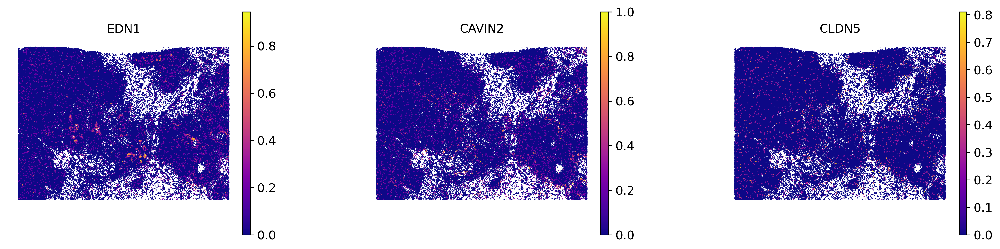

In [21]:
plot_endo = False
gene_list_stroma = ["EDN1", "CAVIN2", "CLDN5"]
percentiles_stroma = get_gene_percentiles_list(
    adata, gene_list_stroma, 99.9, layer="min_max_scaled"
)

for sample in adata.obs[setup.SAMPLE].unique().tolist()[:1]:
    sc.pl.spatial(
        adata=adata_astro[adata_astro.obs[setup.SAMPLE] == sample]
        if plot_endo
        else adata_not_endo[adata_not_endo.obs[setup.SAMPLE] == sample],
        spot_size=100 if plot_endo else 40,
        # color=g3_g1_genes,
        color=gene_list_stroma,
        frameon=False,
        show=False,
        use_raw=False,
        wspace=0.4,
        # vmax=percentiles_stroma,
        # vmax="p99.5",
        layer="min_max_scaled",
        cmap="plasma",
    )

    if plot_endo:
        plt.savefig(f"{figure_dir}_proseg_stroma_endo.svg", bbox_inches="tight", dpi=1000)
    else:
        plt.savefig(f"{figure_dir}_proseg_stroma_not_endo.svg", bbox_inches="tight", dpi=1000)

# Benchmark

In [46]:
adata_ref = ad.read_h5ad(ATLAS_PATH)
print(adata_ref)

sc.tl.rank_genes_groups(
    adata_ref,
    groupby="cell_type",
    groups=["endothelial cell"],
    method="wilcoxon",
    key_added="rank_genes_groups_wilcoxon_cell_type",
    use_raw=False,
    pts=True,
    n_genes=None,
)

AnnData object with n_obs × n_vars = 100064 × 29067
    obs: 'donor_id', 'percent_mito', 'nCount_RNA', 'nFeature_RNA', 'celltype_major', 'celltype_minor', 
'celltype_subset', 'subtype', 'gene_module', 'calls', 'normal_cell_call', 'CNA_value', 'batch_run', 'multiplexed', 
'cryo_state', 'development_stage_ontology_term_id', 'cancer_type', 'ER', 'PR', 'HER2_IHC', 'HER2_ISH', 
'HER2_ISH_ratio', 'Ki67', 'subtype_by_IHC', 'treatment_status', 'treatment_details', 'assay_ontology_term_id', 
'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'sex_ontology_term_id', 
'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'disease_ontology_term_id', 'grade', 
'cell_type_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 
'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 
'feature_type'
    uns: 'citation', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_Three-D', 'X_umap'

In [61]:
df = sc.get.rank_genes_groups_df(
    adata_ref,
    group="endothelial cell",
    key="rank_genes_groups_wilcoxon_cell_type",
    gene_symbols="feature_name",
    # log2fc_min=0.25,
    # pval_cutoff=0.05,
)

df.index = df["feature_name"]

df

,names,scores,logfoldchanges,pvals,pvals_adj,feature_name,pct_nz_group,pct_nz_reference
feature_name,,,,,,,,
RAMP2,ENSG00000131477,124.560837,7.274539,0.0,0.0,RAMP2,0.880438,0.058622
SPARCL1,ENSG00000152583,124.264580,5.688367,0.0,0.0,SPARCL1,0.944610,0.162332
PLVAP,ENSG00000130300,121.725212,8.334961,0.0,0.0,PLVAP,0.855715,0.024012
PECAM1,ENSG00000261371,119.153999,6.026734,0.0,0.0,PECAM1,0.853688,0.075414
GNG11,ENSG00000127920,118.898262,5.650743,0.0,0.0,GNG11,0.860848,0.093512
...,...,...,...,...,...,...,...,...
RPLP1,ENSG00000137818,-61.391865,-0.720872,0.0,0.0,RPLP1,0.957714,0.984729
OAZ1,ENSG00000104904,-61.742897,-1.221867,0.0,0.0,OAZ1,0.742097,0.847187
S100A4,ENSG00000196154,-68.327164,-3.700589,0.0,0.0,S100A4,0.166306,0.580313


In [49]:
g1_g3_genes

Index(['ESM1', 'TCIM', 'DUSP5', 'CDC42EP1', 'PRDM1', 'SQLE', 'VOPP1', 'TRAF4',
       'PCLAF', 'DNTTIP1', 'CCND1', 'KDR', 'ZEB1', 'SNAI1', 'OXTR', 'DAPK3',
       'SEC24A', 'CENPF', 'NDUFA4L2'],
      dtype='object')

In [72]:
proba_de_confident = DE_1_3.g1_g2[
    g1_markers
    & (DE_1_3.g1_g2["lfc_median"] > 0)
    & (DE_1_3.g1_g2["proba_de"] > PROBA_TRES)
    & (DE_1_3.g1_g2["proba_de_g1_n1"] > 0)
]["proba_de_g1_n1"]

proba_de = DE_1_3.g1_g2[
    (DE_1_3.g1_g2["lfc_median"] > 0) & (DE_1_3.g1_g2["proba_de"] > PROBA_TRES)
]["proba_de_g1_n1"]

/tmp/ipykernel_1146455/2429446557.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  proba_de_confident = DE_1_3.g1_g2[


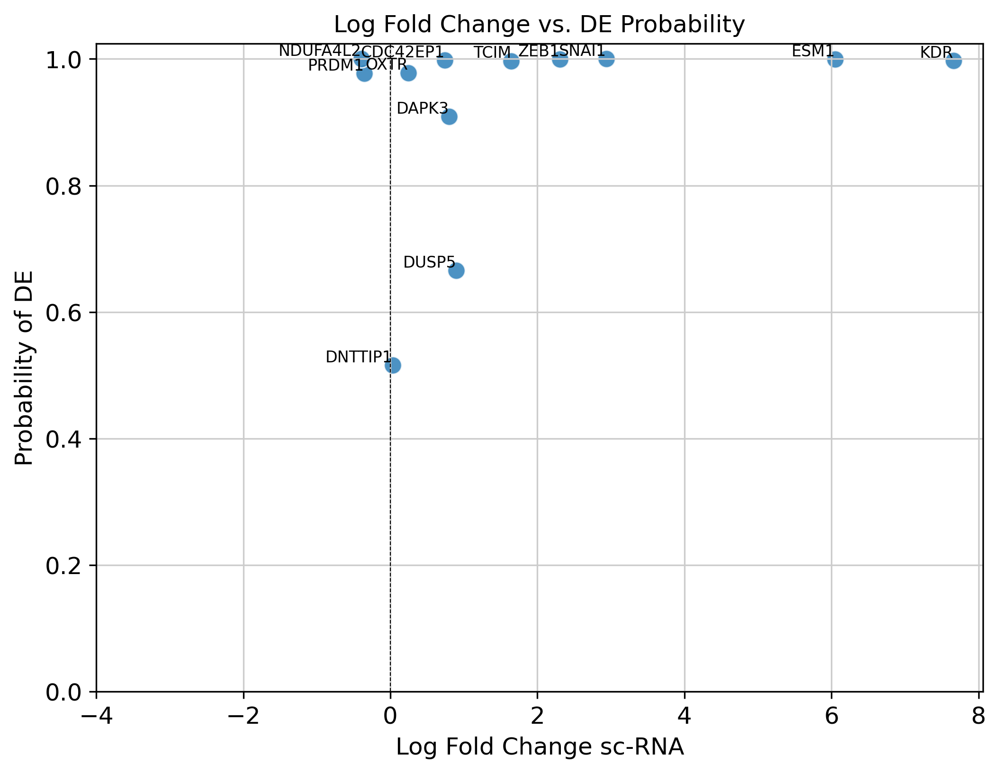

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter to include only genes present in both df and proba_de
common_genes = proba_de_confident.index

# Extract values
logfoldchanges = df.loc[common_genes, "logfoldchanges"]
probabilities = proba_de_confident.loc[common_genes]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=logfoldchanges, y=probabilities, s=80, alpha=0.8)

# Add vertical line at x = 0
plt.axvline(x=0, color="black", linestyle="--", linewidth=0.5)

# Annotate each point with its gene name
for gene, x, y in zip(common_genes, logfoldchanges, probabilities):
    plt.text(x, y, gene, fontsize=8, ha="right", va="bottom")

# Set x-axis limits
plt.xlim(-4, None)  # xmin = -4, xmax remains automatic
plt.ylim(0, None)  # ymin = 0, ymax = 1

# Labels and title
plt.xlabel("Log Fold Change sc-RNA")
plt.ylabel("Probability of DE")
plt.title("Log Fold Change vs. DE Probability")

plt.show()